## CAB Dataset Analysis - Female participants

This notebook focuses on analyzing the Clinical, Anthropometric & Bio-Chemical Survey (CAB) dataset. The dataset can be downloaded at https://www.kaggle.com/datasets/rajanand/cab-survey. 

The dataset has undergone preprocessing steps which includes removing unnecessary variables as well as missing data. More info in the data directory.

The analysis aims to explore the approach proposed in this paper and identify the relevant features in conditional mean and variance for glucose prediction. Specifically, for female participants.

In [ ]:
import sys
sys.path.append("../..")

import math
import numpy as np
import pandas as pd
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split
from knnvs import KnnBag, KnnVar, initialize_knn, roc
import random
import logging
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams['axes.labelsize'] = 9

We load the dataset and select the dependent and independent variables we are going to study. We use the same variables for female and male participants. The array `x` will contain the independent variables while `y` the dependent variable.

In [3]:
random.seed(1)
np.random.seed(1)
grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

df = pd.read_csv('data/CAB_clean.csv')
df = df.loc[(df['sex'] == 2)]

out = 'fasting_blood_glucose_mg_dl'
inp = np.array(["age", "weight", "height", "haemoglobin_level", "bp_systolic", "bp_diastolic", "pulse_rate", "bmi"])

y = df[out].to_numpy().astype('float32')
x = df[inp].to_numpy().astype('float32')
# x = x[0:10000, :]
# y = y[0:10000]

We initialize a kNN model from the data inputs (`x` and `y`) and two grids (`grida` and `gridv` for conditional mean and variance, respectively) for tunning the k value. The method `initialize_knn` returns an instance of kNN for the conditional mean (`knna0`) and for the conditional variance (`knnv0`), along with the features selected (`fa0` and `fv0`) and the best k (`ka0` and `kv0`) for mean and variance, respectively.

Note: The variables `pva0` and `pvv0` contain the p-values corresponding to each feature in the feature selection process of the conditional mean and variance, respectively.

In [4]:
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(x, y, grida, gridv, quantile=(1 - 0.01))
knn0 = KnnVar(knna0, knnv0)
print('Selected features for the conditional mean: {}'.format(inp[fa0]))
print('Selected features for the conditional variance: {}'.format(inp[fv0]))

Women weight/pulse rate - selected features for mean: ['age']
Women weight/pulse rate - selected features variance: ['age' 'height' 'haemoglobin_level' 'bp_systolic' 'bp_diastolic'
 'pulse_rate']


In the following nested loops, we compute the predictions of the conditional mean for the grid `agrig` (age variable) and `rgrid` (pulse rate variable). We use these variables as `age` is a selected feature for the mean, although `pulse_rate` is not.

Note: Although we could analyse how each pair of variables influence glucose, we will limit the representation to the former two, examplifying the feature selection process acuracy. The code adaptation for the other combinations is straighforward. 

In [ ]:
x_mean = np.mean(x, axis=0)

agrid = list(np.arange(40, 80, step=0.1))
rgrid = list(np.arange(55, 120, step=0.1))
ages = []
rates = []
glucoa = []
glucov = []
for a in agrid:
    for r in rgrid:
        xi = np.array([a, x_mean[1], x_mean[2], x_mean[3], x_mean[4], x_mean[5], r, x_mean[7]]).reshape((1, 8)).astype('float32')
        glucoa.append(float(knn0.predict_average(xi, k=ka0)))
        glucov.append(float(knn0.predict_variance(xi, k=kv0)))
        ages.append(a)
        rates.append(r)

dict = {
    "ages": ages,
    "rates": rates,
    "glucoa": glucoa,
    "glucov": glucov
}
df2 = pd.DataFrame(dict)
df2.to_csv('cad_3_avg.csv')

We represent the 3D scatterplot for the glucose conditional mean. As previously stated, only age influences the glucose conditional mean, which rises as patients get older. 

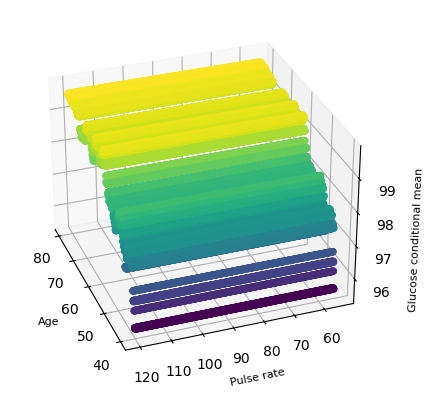

In [66]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df2.ages, df2.rates, df2.glucoa, c=df2.glucoa, cmap='viridis')
ax.set_xlabel('Age')
ax.set_ylabel('Pulse rate')
ax.set_zlabel('Glucose conditional mean')
ax.view_init(elev=30, azim=160)  # elevation and azimuth
plt.savefig('cad_2_avg.png', bbox_inches='tight', pad_inches=0)

In the following nested loops, we compute the predictions of the conditional mean for the grid `wgrig` (weight variable) and `rgrid` (pulse rate variable). We use these variables as `weight` and  `pulse_rate` are selected features for the conditional mean and variance. 

Note: Although we could analyse how each pair of variables influence glucose, we will limit the representation to the former two, examplifying the feature selection process acuracy. The code adaptation for the other combinations is straighforward. 

In [ ]:
x_mean = np.mean(x, axis=0)

wgrid = list(np.arange(40, 150, step=0.1))
rgrid = list(np.arange(55, 120, step=0.1))
weights = []
rates = []
glucoa = []
glucov = []
for w in wgrid:
    for r in rgrid:
        xi = np.array([x_mean[0], w, x_mean[2], x_mean[3], x_mean[4], x_mean[5], r, x_mean[7]]).reshape((1, 8)).astype('float32')
        glucoa.append(float(knn0.predict_average(xi, k=ka0)))
        glucov.append(float(knn0.predict_variance(xi, k=kv0)))
        weights.append(w)
        rates.append(r)

dict = {
    "weights": weights,
    "rates": rates,
    "glucoa": glucoa,
    "glucov": glucov
}
df3 = pd.DataFrame(dict)
df3.to_csv('cad_3_var.csv')

We represent the 3D scatterplot for the glucose conditional standar deviation. Both weight and heart rate proportionally influence the standard deviation, which rises concurrently with them. 

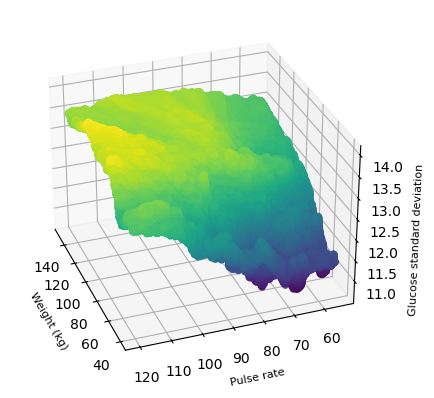

In [67]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
dev = np.sqrt(df3.glucov)
ax.scatter(df3.weights, df3.rates, dev, c=dev, cmap='viridis')
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Pulse rate')
ax.set_zlabel('Glucose standard deviation')
ax.grid(True)
ax.set_facecolor('white')  # Adjust background color
ax.view_init(elev=30, azim=160)  # elevation and azimuth
plt.savefig('cad_2_var.png', bbox_inches='tight', pad_inches=0)